<h1><font color="#113D68" size=6>Deep Learning en Python con PyTorch</font></h1>

<h1><font color="#113D68" size=5>Parte 3. MultiLayer Perceptron</font></h1>

<h1><font color="#113D68" size=4>4. Crear un bucle de entrenamiento</font></h1>

<br><br>
<div style="text-align: right">
<font color="#113D68" size=3>Manuel Castillo Cara</font><br>

</div>

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
More information about [Manuel Castillo-Cara](https://www.manuelcastillo.eu/)

<div class="alert alert-block alert-info">

<i class="fa fa-info-circle" aria-hidden="true"></i>
Puedes ver más cursos de Inteligencia Artificial, Machine Learning y Deep Learning en mi [página web](https://www.manuelcastillo.eu/udemy/)


---

<a id="indice"></a>
<h2><font color="#004D7F" size=5>Índice</font></h2>

* [0. Contexto](#section0)
* [1. Elementos del entrenamiento de un modelo de aprendizaje profundo](#section1)
* [2. Recolectando estadísticas durante el entrenamiento](#section2)
* [3. Uso de `tqdm` para reportar el progreso del entrenamiento](#section3)


---
<a id="section0"></a>
# <font color="#004D7F" size=6> 0. Contexto</font>

PyTorch proporciona muchos bloques de construcción para un modelo de aprendizaje profundo, pero un ciclo de entrenamiento no forma parte de ellos. Esto te da la flexibilidad de hacer lo que quieras durante el entrenamiento, pero existe una estructura básica que es común en la mayoría de los casos de uso.

En este capítulo, verás cómo crear un ciclo de entrenamiento que proporcione información esencial para el entrenamiento de tu modelo, con la opción de mostrar cualquier información que desees. Después de completar este capítulo, sabrás:

- Los bloques básicos de un ciclo de entrenamiento
- Cómo usar `tqdm` para mostrar el progreso del entrenamiento

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
[PyTorch tutorials.](https://pytorch.org/tutorials/)

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
[PyTorch Documentation](https://pytorch.org/docs/stable/index.html).

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre [`tqdm`](https://github.com/tqdm/tqdm).

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
PyTorch API. [`torch.optim`](https://pytorch.org/docs/stable/optim.html).

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
PyTorch Tutorials. [Optimizing Model Parameters](https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html).

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section1"></a>
# <font color="#004D7F" size=6>1. Elementos del entrenamiento de un modelo de aprendizaje profundo</font>

- El diseño del modelo especifica el algoritmo para manipular una entrada y producir una salida.

- Los parámetros del modelo (pesos, sesgos, kernels) se ajustan durante el entrenamiento.

- El entrenamiento implica alimentar datos de muestra al modelo para que un optimizador ajuste estos parámetros.

- Se recomienda dividir el conjunto de datos en dos partes: train/test.

    - El conjunto de train se divide en lotes y se usa en el ciclo de entrenamiento.

    - El conjunto de test se utiliza para evaluar el rendimiento del modelo en datos no vistos.

- El ciclo de entrenamiento incluye un pase hacia adelante (entrada a salida) y un pase hacia atrás (cálculo de gradientes).

- Los gradientes se utilizan en el algoritmo de descenso de gradiente para ajustar los parámetros del modelo.

In [2]:
import numpy as np
import torch

dataset = np.loadtxt('Datasets/pima-indians-diabetes.csv', delimiter=',')
X = dataset[:,0:8]
y = dataset[:,8]
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

Xtrain = X[:700]
ytrain = y[:700]
Xtest = X[700:]
ytest = y[700:]

Puedes reutilizar el modelo, la función de pérdida y el optimizador de un capítulo anterior:

In [3]:
import torch.nn as nn
import torch.optim as optim

model = nn.Sequential(
    nn.Linear(8, 12),
    nn.ReLU(),
    nn.Linear(12, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)
print(model)

loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Sequential(
  (0): Linear(in_features=8, out_features=12, bias=True)
  (1): ReLU()
  (2): Linear(in_features=12, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)


Con los datos y el modelo listos, este es el ciclo de entrenamiento mínimo, con el pase hacia adelante y hacia atrás en cada paso.

En el ciclo interno:
1. Toma cada lote del conjunto de datos y evalúa la pérdida.

2. La pérdida es un tensor de PyTorch que recuerda cómo se obtiene su valor.

3. Luego, reinicia todos los gradientes (`zero_grad()`) que maneja el optimizador

4. Llama a `loss.backward()` para ejecutar el algoritmo de retropropagación.

6. Luego, al llamar a `step()`, el optimizador verificará cada parámetro que gestiona y los actualizará.


In [6]:
n_epochs = 100
batch_size = 10
batches_per_epoch = len(Xtrain) // batch_size

for epoch in range(n_epochs):
    for i in range(batches_per_epoch):
        start = i * batch_size
        Xbatch = Xtrain[start:start + batch_size]
        ybatch = ytrain[start:start + batch_size]
        #Forward
        y_pred = model(Xbatch)
        loss = loss_fn(y_pred, ybatch)
        print(f"epoch {epoch} step {i} loss {loss}")
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

Se han truncado las últimas 5000 líneas del flujo de salida.
epoch 28 step 40 loss 0.5933948159217834
epoch 28 step 41 loss 0.5316840410232544
epoch 28 step 42 loss 0.5373637676239014
epoch 28 step 43 loss 0.37710121273994446
epoch 28 step 44 loss 0.649110734462738
epoch 28 step 45 loss 0.5024842619895935
epoch 28 step 46 loss 0.3830159604549408
epoch 28 step 47 loss 0.46599632501602173
epoch 28 step 48 loss 0.40420666337013245
epoch 28 step 49 loss 0.5176037549972534
epoch 28 step 50 loss 0.4830706715583801
epoch 28 step 51 loss 0.5474610328674316
epoch 28 step 52 loss 0.32324835658073425
epoch 28 step 53 loss 0.42031174898147583
epoch 28 step 54 loss 0.7730982899665833
epoch 28 step 55 loss 0.2288047820329666
epoch 28 step 56 loss 0.38215869665145874
epoch 28 step 57 loss 0.44916096329689026
epoch 28 step 58 loss 0.6525493860244751
epoch 28 step 59 loss 0.5100774765014648
epoch 28 step 60 loss 0.4849148690700531
epoch 28 step 61 loss 0.5535420179367065
epoch 28 step 62 loss 0.2779737

Una vez que todo esté hecho, puedes ejecutar el modelo con el conjunto de test para evaluar su rendimiento.

In [7]:
with torch.no_grad():
  y_pred = model(Xtest)
  y_pred = (y_pred > 0.5).float()
  accuracy = (y_pred == ytest).float().mean()
print("Accuracy {:.2f}".format(accuracy * 100))


Accuracy 75.00


---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section2"></a>
# <font color="#004D7F" size=6>2. Recolectando estadísticas durante el entrenamiento</font>

- El ciclo de entrenamiento básico es adecuado para modelos pequeños con entrenamiento rápido.

- Para modelos más grandes o conjuntos de datos extensos, se necesita monitorear el progreso del entrenamiento.

- Aspectos importantes a observar durante el entrenamiento:

  • Métrica de pérdida en cada paso (se espera que disminuya).

  • Otras métricas, como el accuracy en el conjunto de entrenamiento que vaya aumentado.

  • Evaluación del modelo con el conjunto test al final de cada época.

  • Visualización de todas las métricas al final del entrenamiento.
  
- Se requiere código adicional en el ciclo de entrenamiento para implementar estas funcionalidades.

In [8]:
n_epochs = 50    # number of epochs to run
batch_size = 10  # size of each batch
batches_per_epoch = len(Xtrain) // batch_size

train_loss = []
train_acc = []
test_acc = []

for epoch in range(n_epochs):
    for i in range(batches_per_epoch):
        start = i * batch_size
        Xbatch = Xtrain[start:start + batch_size]
        ybatch = ytrain[start:start + batch_size]
        y_pred = model(Xbatch)
        loss = loss_fn(y_pred, ybatch)
        acc = (y_pred.round() == ybatch).float().mean()
        train_loss.append(float(loss))
        train_acc.append(float(acc))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"epoch {epoch} step {i} loss {loss} accuracy {acc}")
    y_pred = model(Xtest)
    acc = (y_pred.round() == ytest).float().mean()
    test_acc.append(float(acc))
    print(f"End of {epoch}, accuracy {acc}")

/tmp/ipykernel_4411/2543214240.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  train_loss.append(float(loss))


epoch 0 step 0 loss 0.5870656967163086 accuracy 0.699999988079071
epoch 0 step 1 loss 0.5752226710319519 accuracy 0.6000000238418579
epoch 0 step 2 loss 0.5641089677810669 accuracy 0.6000000238418579
epoch 0 step 3 loss 0.5221067070960999 accuracy 0.699999988079071
epoch 0 step 4 loss 0.6181426644325256 accuracy 0.4000000059604645
epoch 0 step 5 loss 0.49719661474227905 accuracy 0.800000011920929
epoch 0 step 6 loss 0.5997395515441895 accuracy 0.6000000238418579
epoch 0 step 7 loss 0.3522016406059265 accuracy 0.800000011920929
epoch 0 step 8 loss 0.4567337930202484 accuracy 0.8999999761581421
epoch 0 step 9 loss 0.520898699760437 accuracy 0.699999988079071
epoch 0 step 10 loss 0.5879063010215759 accuracy 0.699999988079071
epoch 0 step 11 loss 0.4515852928161621 accuracy 0.699999988079071
epoch 0 step 12 loss 0.8528100848197937 accuracy 0.699999988079071
epoch 0 step 13 loss 0.34673115611076355 accuracy 1.0
epoch 0 step 14 loss 0.32486826181411743 accuracy 0.800000011920929
epoch 0 step

- Se recolectan la pérdida y la precisión en listas durante el entrenamiento.

- Es posible graficar estas métricas utilizando `matplotlib`.

- Se debe tener en cuenta que las estadísticas del conjunto de entrenamiento se recolectan en cada paso.

- El accuracy del conjunto de test solo se evalúa al final de cada época.

- Para una comparación adecuada, se recomienda mostrar el accuracy promedio del ciclo de entrenamiento por época.

- La primera gráficaf muestra la pérdida durante el entrenamiento.

- La segunda gráfica presenta el accuracy promedio por época en el conjunto de test.

- Se observa una disminución en la pérdida de entrenamiento a medida que avanzan los pasos.

- El accuracy en test muestra una tendencia ascendente a lo largo de las épocas, indicando una mejora en el rendimiento del modelo.

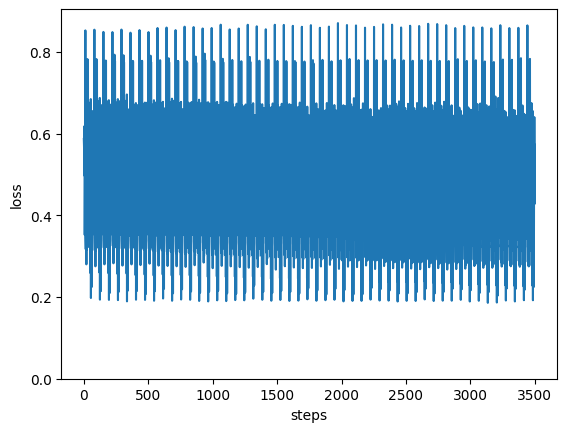

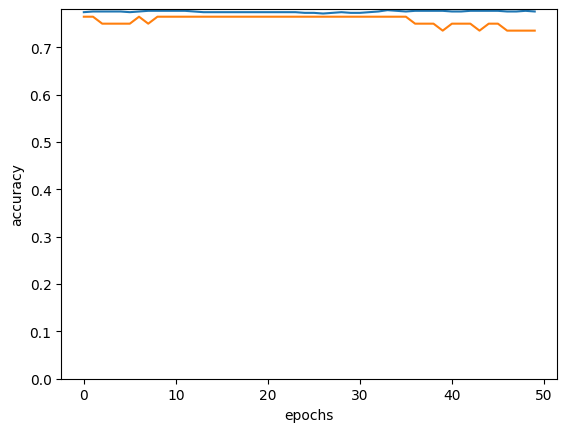

In [9]:
import matplotlib.pyplot as plt

plt.plot(train_loss)
plt.xlabel("steps")
plt.ylabel("loss")
plt.ylim(0)
plt.show()

avg_train_acc = []
for i in range(n_epochs):
    start = i * batch_size
    average = sum(train_acc[start:start+batches_per_epoch]) / batches_per_epoch
    avg_train_acc.append(average)

plt.plot(avg_train_acc, label="train")
plt.plot(test_acc, label="test")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0)
plt.show()

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section3"></a>
# <font color="#004D7F" size=6>3. Uso de `tqdm` para reportar el progreso del entrenamiento</font>

Ahora veamos el primer código:
- La ejecución del código anterior genera numerosas líneas de salida durante el entrenamiento.

- Se puede implementar una barra de progreso animada para visualizar el avance del entrenamiento.

- La biblioteca `tqdm` es una herramienta popular para crear barras de progreso.

- La conversión del código para usar `tqdm` es sencilla.

#### Características:
- Utiliza `tqdm.trange()` para crear la barra de progreso, que es similar a `range()`.

- Dentro del bucle `for`, la variable `i` actúa como el índice del lote (batch), y luego se calcula `start = i * batch_size` en cada iteración para determinar el índice inicial de cada lote.

- Cada lote es seleccionado dentro del bucle utilizando este índice calculado (`start`).

#### Resumen:
Este código calcula los índices `start` dinámicamente dentro del bucle principal para cada lote basado en el número de `batches_per_epoch`.

In [10]:
import tqdm

n_epochs = 50    # number of epochs to run
batch_size = 10  # size of each batch
batches_per_epoch = len(Xtrain) // batch_size

# collect statistics
train_loss = []
train_acc = []
test_acc = []

for epoch in range(n_epochs):
    with tqdm.trange(batches_per_epoch, unit='batch', mininterval=0) as bar:
        bar.set_description(f"Epoch {epoch}")
        for i in bar:
            start = i * batch_size
            Xbatch = Xtrain[start:start + batch_size]
            ybatch = ytrain[start:start + batch_size]

            #Paso hacia adelante (forward pass)
            y_pred = model(Xbatch)
            loss = loss_fn(y_pred, ybatch)
            acc = (y_pred.round() == ybatch).float().mean()

            #Almacenar métricas
            train_loss.append(float(loss))
            train_acc.append(float(acc))

            #Paso hacia atrás (backward pass)
            optimizer.zero_grad()
            loss.backward()

            #Actualizar parámetros
            optimizer.step()

            # mostrar el progreso
            bar.set_postfix(
                loss=float(loss),
                acc=f"{float(acc) * 100:.2f}%"
            )

    # evaluar el modelo al final de la época
    y_pred = model(Xtest)
    acc = (y_pred.round() == ytest).float().mean()
    test_acc.append(float(acc))
    print(f"Fin de la época {epoch}, Accuracy {acc}")


Epoch 0: 100%|██████████| 70/70 [00:00<00:00, 188.40batch/s, acc=60.00%, loss=0.582]


Fin de la época 0, Accuracy 0.75


Epoch 1: 100%|██████████| 70/70 [00:00<00:00, 210.15batch/s, acc=70.00%, loss=0.543]


Fin de la época 1, Accuracy 0.7352941036224365


Epoch 2: 100%|██████████| 70/70 [00:00<00:00, 202.10batch/s, acc=70.00%, loss=0.577]


...

Fin de la época 47, Accuracy 0.720588207244873


Epoch 48: 100%|██████████| 70/70 [00:00<00:00, 222.89batch/s, acc=70.00%, loss=0.547]


Fin de la época 48, Accuracy 0.720588207244873


Epoch 49: 100%|██████████| 70/70 [00:00<00:00, 214.37batch/s, acc=70.00%, loss=0.542]

Fin de la época 49, Accuracy 0.720588207244873


Ahora veamos el siguiente código:
- `tqdm` crea un iterador con `trange()`, similar a la función `range()` de Python.

- Se puede iterar sobre este iterador dentro del ciclo de entrenamiento.

- La barra de progreso se puede actualizar modificando su descripción o los datos de "postfix".

- Las actualizaciones deben realizarse antes de que termine el ciclo.

- La función `set_postfix()` permite mostrar cualquier información deseada en la barra de progreso.

- Además de `trange()`, existe la función `tqdm()` que itera sobre una lista existente.

- `tqdm()` puede ser más fácil de usar en algunos casos.

#### Características:

- Antes del bucle principal, crea una lista `starts` que contiene todos los índices iniciales (`start = i * batch_size`) de los lotes (batches) para cada época.

- Luego, usa `tqdm.tqdm()` para iterar directamente sobre esa lista `starts`.

- No necesita calcular `start` dentro del bucle, ya que los valores ya están precomputados y almacenados en la lista `starts`.


#### Resumen:

Este código precomputa los índices iniciales (`start`) para todos los lotes antes de comenzar el bucle de épocas. Luego, itera directamente sobre esos valores en lugar de calcularlos dinámicamente en cada iteración.

In [11]:
import tqdm

# generar los puntos de inicio para cada batch
starts = [i * batch_size for i in range(batches_per_epoch)]

for epoch in range(n_epochs):
    # usar tqdm para la barra de progreso
    with tqdm.tqdm(starts, unit='batch', mininterval=0) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # tomar un lote (batch)
            Xbatch = Xtrain[start:start + batch_size]
            ybatch = ytrain[start:start + batch_size]

            # paso hacia adelante (forward pass)
            y_pred = model(Xbatch)
            loss = loss_fn(y_pred, ybatch)
            acc = (y_pred.round() == ybatch).float().mean()

            # almacenar las métricas
            train_loss.append(float(loss))
            train_acc.append(float(acc))

            # paso hacia atrás (backward pass)
            optimizer.zero_grad()
            loss.backward()

            # actualizar los pesos
            optimizer.step()

            # actualizar la barra de progreso
            bar.set_postfix(
                loss=float(loss),
                acc=f"{float(acc) * 100:.2f}%"
            )

    # evaluar el modelo al final de la época
    y_pred = model(Xtest)
    acc = (y_pred.round() == ytest).float().mean()
    test_acc.append(float(acc))
    print(f"Fin de la época {epoch}, Accuracy {acc}")


Epoch 0: 100%|██████████| 70/70 [00:00<00:00, 190.79batch/s, acc=70.00%, loss=0.55]


Fin de la época 0, Accuracy 0.720588207244873


Epoch 1: 100%|██████████| 70/70 [00:00<00:00, 174.92batch/s, acc=70.00%, loss=0.546]


Fin de la época 1, Accuracy 0.720588207244873


Epoch 2: 100%|██████████| 70/70 [00:00<00:00, 180.93batch/s, acc=70.00%, loss=0.546]


...

Fin de la época 47, Accuracy 0.7352941036224365


Epoch 48: 100%|██████████| 70/70 [00:00<00:00, 231.70batch/s, acc=70.00%, loss=0.522]


Fin de la época 48, Accuracy 0.7352941036224365


Epoch 49: 100%|██████████| 70/70 [00:00<00:00, 227.63batch/s, acc=70.00%, loss=0.525]

Fin de la época 49, Accuracy 0.7352941036224365


### Diferencias Clave entre el primer y segundo código:

1. **Cálculo del índice `start`**:

   - En el primer código, el índice `start` se calcula dinámicamente dentro del bucle usando el índice `i`.

   - En el segundo código, los índices `start` se calculan antes de que comience el bucle y se almacenan en la lista `starts`, eliminando la necesidad de calcularlos dentro del bucle.

2. **Uso de `tqdm`**:

   - El primer código usa `tqdm.trange()`, que es una versión de `range()` con una barra de progreso.

   - El segundo código usa `tqdm.tqdm()` para iterar directamente sobre la lista de inicios precomputados (`starts`).

Ambos códigos funcionan de manera similar, pero el segundo es más eficiente si los índices iniciales de los lotes son constantes o si prefieres precomputar estos valores para mayor claridad.

<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<div style="text-align: right"> <font size=6><i class="fa fa-coffee" aria-hidden="true" style="color:#004D7F"></i> </font></div>